<a href="https://colab.research.google.com/github/DLmandagaran/DS/blob/main/ProyectoParteIII%2BMandagaran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis 360 del Ciclo de Vida del Cliente en E-commerce (Veeqo)**
## **Abstract**

Importamos la base df_retail que contiene una cantidad de 37 columnas y una cantidad de filas de 84.063. Esta base consiste en registros de compañías que utilizan la plataforma de gestión de inventario y envíos **Veeqo**. El dataset abarca dimensiones críticas del negocio B2B (Business-to-Business), permitiendo un análisis profundo sobre la adopción de tecnología en el comercio minorista de mercado medio. Para dejar en claro **veeqo** es una plataforma de gestion de inventarios y envios como establecimos anteriormente pero es de la compañia **amazon**, especificamente es un software de envio gratuito de esta ultima.

Los datos constan de **37 columnas** como dijimos anteriormente,  que describen el perfil del cliente, desde su captación (**MARKETING_CHANNEL**, **SIGNUP_TYPE**) hasta su comportamiento operativo (**ACTIVE_CHANNELS**, **WAREHOUSES**, **ACTIVE_USERS_L_28D**). A diferencia de un dataset transaccional típico de consumidor final, este recurso se centra en la "salud" de la cuenta del vendedor, ofreciendo métricas de engagement (compromiso) como la recencia de uso (**LAST_PAGE_LOADED_AT**) y la complejidad de su operación logística.

El objetivo principal de este análisis es identificar los factores que distinguen a los usuarios activos y de alto valor (High Value) de aquellos que permanecen en fase de prueba o abandonan la plataforma (Churn).

A través de la segmentación por estado de suscripción y nivel de integración de canales (Amazon, eBay, Shopify, etc.), se busca comprender cómo la infraestructura tecnológica del cliente influye en su fidelidad y crecimiento dentro de la plataforma.

---



##📊 **Glosario de Variables - Dataset Veeqo Amazon**


1- **COMPANY_ID** (float64): Identificador único numérico de la empresa.

2- **COMPANY_NAME** (object): Nombre legal o comercial de la empresa registrada.

3- **COMPANY_CREATED_AT** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Fecha y hora exacta de registro de la empresa en la plataforma.

4- **SUBSCRIPTION_STATUS** (object): Estado actual de la suscripción (ej. activo, cancelado, periodo de prueba).

5- **VEEQO_PRODUCT_NAME** (object): Nombre del plan o producto específico de Veeqo contratado por el cliente.

6- **PRODUCT**(object): Tipo o categoría de producto principal que comercializa el vendedor.

7- **DECILE** (float64): Clasificación del cliente en deciles (1-10) basada en su valor o actividad para análisis RFM.

8- **SELLER_TYPE** (object): Categorización del tipo de vendedor (ej. Retail, Wholesale, marca propia).

9- **SIGNUP_TYPE** (object): Método o canal por el cual el usuario realizó su registro inicial.

10- **ACTIVE_SHIPPER** (object): Indicador de si la empresa realiza envíos de forma activa a través de la plataforma.

11- **COUNTRY** (object): País de operación o ubicación principal de la empresa.

12- **EMAIL** (object): Correo electrónico de contacto principal de la cuenta.

13- **PHONE** (Inicialmente float64 pero es necesario cambiarlo ya que no es un dato numérico): Número telefónico de contacto (presenta alta tasa de valores nulos).

14- **ACTIVE_CHANNELS** (float64): Cantidad de canales de venta conectados que están actualmente activos.

15- **INACTIVE_CHANNELS** (float64): Cantidad de canales de venta que fueron conectados pero se encuentran inactivos.

16- **UNIQUE_CHANNELS_ACTIVE_EXCL_DIRECT_AMAZON** (float64): Conteo de canales activos únicos, excluyendo la integración directa de Amazon.

17- **UNIQUE_CHANNELS_ACTIVE_EXCL_AMAZON** (float64): Conteo de canales activos únicos, excluyendo todos los canales relacionados con Amazon.

18- **UNIQUE_CHANNELS** (object): Listado o detalle de los nombres de los canales únicos vinculados.

19- **PQL_DATE** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Fecha en que el usuario calificó como Lead de Producto (Product Qualified Lead).

20- **FIRST_SHIPMENT_DATE** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Fecha en la que la empresa realizó su primer envío usando Veeqo.

21- **LAUNCHED_DATE** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Fecha oficial en la que la cuenta del cliente completó su configuración y salió a producción.

22- **ACTIVATED_WEEK** (Inicialmente object pero deberia cambiarse a tipo date): Semana en la que se activó la cuenta para análisis de cohortes temporales.

23- **LAST_SHIPMENT_DATE** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Fecha del envío más reciente registrado (clave para medir la Recencia).

24- **LAST_PAGE_LOADED_AT** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Marca de tiempo de la última actividad del usuario en la interfaz de la plataforma.

25- **ACTIVE_USERS_L_28D** (float64): Cantidad de usuarios únicos de la empresa que han estado activos en los últimos 28 días.

26- **ALL_USERS_COUNT** (float64): Número total de usuarios registrados bajo la misma cuenta de empresa.

27- **ADMIN_USER_COUNT** (float64): Número de usuarios que poseen privilegios de administrador en la cuenta.

28- **FIRST_SALES_INTERACTION** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Fecha de la primera interacción documentada con el equipo de ventas.

29- **MARKETING_CHANNEL** (object): Canal de marketing principal a través del cual se adquirió al cliente.

30- **MARKETING_SUB_CHANNEL** (object): Sub-categoría o fuente específica del canal de marketing de procedencia.

31- **MARKETING_CAMPAIGN** (object): Nombre de la campaña de marketing específica que generó el registro del usuario.

32- **MOS_ACTIVATED_AT** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Fecha de activación de funciones logísticas avanzadas.

33- **UPGRADED_TO_POWER_AT** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Fecha en la que el cliente cambió su plan a una versión superior ("Power").

34- **WAREHOUSES** (float64): Cantidad total de almacenes o bodegas físicas registradas por la empresa.

35- **FBA_WAREHOUSES** (int64): Cantidad de almacenes gestionados bajo la modalidad Fulfillment by Amazon. Donde FBA (Fulfillment by Amazon)  es el proceso de entrega de pedidos a los clientes, desde el inventario, pasando por el empaquetado de producto, hasta la entrega de paquetes y manejo de retornos en e-commerce. Implica todas las actividades desde el momento en que se recibe un pedido hasta que se entrega al cliente.

36- **FIRST_IMPORTED_ORDER** (Inicialmente object pero es necesario cambiar el tipo de dato a datetime): Fecha en la que se importó la primera orden de venta desde un canal externo.

37- **FIRST_CHANNEL_CONNECTED** ( Inicialmente object pero deberia cambiarse a tipo date): fecha enla que el usuario se vinculo en el primer canal de ventas que el usuario vinculó a su cuenta de Veeqo.

##**📊 Importamos el dataset**

In [ ]:
import pandas as pd

# si ya estaban definidas no pasa nada, se sobrescriben con el mismo valor
sheet_id = '1lh5AACg42dKT8NWyR-Gi_pV9rPNqdMEFqniMVNA4jRw'
gid = '573541234'

url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&gid={gid}'

# lectura del CSV publicado
df_retail = pd.read_csv(url)

print("DataFrame 'df_retail' cargado exitosamente. Aquí están las últimas 5 filas:")
# en Jupyter es más cómodo usar display para ver el dataframe
from IPython.display import display
display(df_retail.tail())

DataFrame 'df_retail' cargado exitosamente. Aquí están las últimas 5 filas:


,COMPANY_ID,COMPANY_NAME,COMPANY_CREATED_AT,SUBSCRIPTION_STATUS,VEEQO_PRODUCT_NAME,PRODUCT,DECILE,SELLER_TYPE,SIGNUP_TYPE,ACTIVE_SHIPPER,...,FIRST_SALES_INTERACTION,MARKETING_CHANNEL,MARKETING_SUB_CHANNEL,MARKETING_CAMPAIGN,MOS_ACTIVATED_AT,UPGRADED_TO_POWER_AT,WAREHOUSES,FBA_WAREHOUSES,FIRST_IMPORTED_ORDER,FIRST_CHANNEL_CONNECTED
84058,49.890,Fresh Heads,"mayo 24, 2023, 8:53 p. m.",trialing,veeqo-shipping-us,veeqo-shipping,5.0,Scaler,Amazon SSO,NaN,...,NaN,Direct,NaN,NaN,NaN,NaN,2.0,0,"marzo 9, 2023, 12:00 a. m.","mayo 24, 2023, 8:53 p. m."
84059,264.492,Bolt Nexus,"junio 9, 2025, 11:11 p. m.",trialing,veeqo-power-us,veeqo-power,9.0,Starter,Amazon SSO,NaN,...,NaN,MYO Banner,NaN,NaN,NaN,"junio 9, 2025, 11:11 p. m.",2.0,0,"junio 9, 2025, 12:00 a. m.","junio 9, 2025, 11:11 p. m."
84060,139.452,WC SPLY,"diciembre 17, 2024, 5:58 a. m.",trialing,veeqo-power-us,veeqo-power,7.0,Scaler,Amazon SSO,NaN,...,NaN,Brand Performance,Paid Search,Brand-Search,NaN,"diciembre 17, 2024, 5:58 a. m.",2.0,0,"diciembre 14, 2024, 12:00 a. m.","diciembre 17, 2024, 5:58 a. m."
84061,95.962,Shore Retail,"septiembre 17, 2024, 4:49 p. m.",trialing,veeqo-power-gb,veeqo-power,NaN,NaN,Amazon SSO,NaN,...,NaN,MYO Banner,NaN,NaN,NaN,"septiembre 17, 2024, 4:49 p. m.",2.0,0,NaN,"septiembre 17, 2024, 4:49 p. m."
84062,138.972,Meemgreen,"diciembre 10, 2024, 9:11 p. m.",trialing,veeqo-power-gb,veeqo-power,9.0,Starter,Amazon SSO,NaN,...,NaN,Direct,NaN,NaN,"diciembre 18, 2024, 11:00 p. m.","diciembre 10, 2024, 9:11 p. m.",2.0,0,"noviembre 6, 2024, 12:00 a. m.","diciembre 10, 2024, 9:11 p. m."


# **Limpieza y transformación de datos**

Basado en el glosario, armamos una lista detallada de las columnas que se deben cambiar el tipo de dato porque su tipo de dato actual no coincide con su naturaleza técnica (fechas, booleanos o IDs).

He dividido las transformaciones en tres grupos principales para hacerlo en la seccion correspondiente:

####**a. <u>Transformación a tipo Fecha (datetime)**</u>

Estas columnas aparecen como object (texto), pero son marcas de tiempo. Es fundamental transformarlas para poder calcular la Recencia en el análisis RFM (El análisis *RFM [* "Recencia", "Frecuencia" y "Valor Monetario"] es una técnica de marketing utilizada para segmentar a los clientes en función de su comportamiento de compra.) o hacer análisis temporales.

3- **COMPANY_CREATED_AT**

19- **PQL_DATE**

20- **FIRST_SHIPMENT_DATE**

21- **LAUNCHED_DATE**

22- **ACTIVATED_WEEK**

23- **LAST_SHIPMENT_DATE**

24- **LAST_PAGE_LOADED_AT**

28- **FIRST_SALES_INTERACTION**

32- **MOS_ACTIVATED_AT**

33- **UPGRADED_TO_POWER_AT**

36- **FIRST_IMPORTED_ORDER**

37- **FIRST_CHANNEL_CONNECTED**

####**b. <u>Transformación a tipo Texto o Categórico (object / str)</u>**

Estas columnas aparecen como números (float64), pero no se deben realizar operaciones matemáticas con ellas. Sumar IDs o números de teléfono no tiene sentido.

1- **COMPANY_ID:** Debe ser object o int64 (si no tiene decimales), ya que es un identificador único.

13- **PHONE:** Debe ser object. Al estar como float64, Python puede intentar leerlo con notación científica (ej: 5.5E+9) y corromper el número. Además, los teléfonos pueden empezar con "+".

####**c. <u>Transformación a tipo Entero (int64)**</u>
Pandas suele asignar float64 a columnas numéricas si estas tienen valores nulos (NaN). Si después de limpiar los nulos se quieren valores exactos, estas deberían ser enteros:

14- **ACTIVE_CHANNELS**

15- **INACTIVE_CHANNELS**

25- **ACTIVE_USERS_L_28D**

26- **ALL_USERS_COUNT**

27- **ADMIN_USER_COUNT**

34- **WAREHOUSES**

In [ ]:
df_retail.info() # (informacion de las columnas que posee el dataset, en este momento todavia no se realizo la transformacion de los tipos de datos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84063 entries, 0 to 84062
Data columns (total 37 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   COMPANY_ID                                 84063 non-null  float64
 1   COMPANY_NAME                               84039 non-null  object 
 2   COMPANY_CREATED_AT                         84063 non-null  object 
 3   SUBSCRIPTION_STATUS                        84063 non-null  object 
 4   VEEQO_PRODUCT_NAME                         84063 non-null  object 
 5   PRODUCT                                    84063 non-null  object 
 6   DECILE                                     49422 non-null  float64
 7   SELLER_TYPE                                49402 non-null  object 
 8   SIGNUP_TYPE                                84063 non-null  object 
 9   ACTIVE_SHIPPER                             16878 non-null  object 
 10  COUNTRY               

Realizamos el arreglo de los tipos de datos **fecha** que estan en **object**, los de tipo **numerico** que deberian ser tipo **object** y finalmente los que tienen tipo de dato **enteros** aplicamos la siguiente estrategia para los valores nulos

In [ ]:
import re
import pandas as pd

# a. Transformación a tipo Fecha (datetime)
datetime_cols = [
    'COMPANY_CREATED_AT',
    'PQL_DATE',
    'FIRST_SHIPMENT_DATE',
    'LAUNCHED_DATE',
    'LAST_SHIPMENT_DATE',
    'LAST_PAGE_LOADED_AT',
    'FIRST_SALES_INTERACTION',
    'MOS_ACTIVATED_AT',
    'UPGRADED_TO_POWER_AT',
    'FIRST_IMPORTED_ORDER',
    'ACTIVATED_WEEK',
    'FIRST_CHANNEL_CONNECTED'
]

# Mapping for Spanish month names to English
month_mapping = {
    'enero': 'January', 'febrero': 'February', 'marzo': 'March', 'abril': 'April',
    'mayo': 'May', 'junio': 'June', 'julio': 'July', 'agosto': 'August',
    'septiembre': 'September', 'octubre': 'October', 'noviembre': 'November',
    'diciembre': 'December'
}

for col in datetime_cols:
    if col in df_retail.columns and df_retail[col].dtype == 'object':
        # Copia de la columna para evitar warnings de Pandas
        temp_col = df_retail[col].copy()

        # Reemplazar meses en español por inglés (sin regex es más eficiente aquí)
        for sp_month, en_month in month_mapping.items():
            temp_col = temp_col.str.replace(sp_month, en_month, case=False, regex=False)

        # Usar REGEX para reemplazar 'a. m.' y 'p. m.' manejando cualquier tipo de espacio u omisión de los mismos (ej: a. m., a.m., a. m.)
        temp_col = temp_col.str.replace(r'a\.\s*m\.', 'AM', case=False, regex=True)
        temp_col = temp_col.str.replace(r'p\.\s*m\.', 'PM', case=False, regex=True)

        # Convertimos a datetime SIN forzar el formato, de esa manera Pandas infiere fechas como "May 25, 2023" que no tienen hora
        df_retail[col] = pd.to_datetime(temp_col, errors='coerce')


# b. Transformación a tipo Texto o Categórico (object / str)
df_retail['COMPANY_ID'] = df_retail['COMPANY_ID'].astype(str)

# Transformar 'PHONE' a object
df_retail['PHONE'] = df_retail['PHONE'].astype(str).replace({'nan': None})


# c. Transformación a tipo Entero (int64)
int_cols = [
    'ACTIVE_CHANNELS',
    'INACTIVE_CHANNELS',
    'ACTIVE_USERS_L_28D',
    'ALL_USERS_COUNT',
    'ADMIN_USER_COUNT',
    'WAREHOUSES'
]

for col in int_cols:
    if col in df_retail.columns:
        # Rellenar NaN con 0 antes de convertir a int64.
        df_retail[col] = df_retail[col].fillna(0).astype('int64')

print("Transformaciones de tipos de datos completadas. Aquí está la información actualizada del DataFrame:")
df_retail.info()

C:\Users\damia\AppData\Local\Temp\ipykernel_21480\2567746351.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_retail[col] = pd.to_datetime(temp_col, errors='coerce')
C:\Users\damia\AppData\Local\Temp\ipykernel_21480\2567746351.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_retail[col] = pd.to_datetime(temp_col, errors='coerce')
C:\Users\damia\AppData\Local\Temp\ipykernel_21480\2567746351.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_retail[col] = pd.to_datetime(temp_col, errors='coerce')
C:\Users\damia\AppData\Local\Temp\ipykernel_21480\2567746351.

Transformaciones de tipos de datos completadas. Aquí está la información actualizada del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84063 entries, 0 to 84062
Data columns (total 37 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   COMPANY_ID                                 84063 non-null  object        
 1   COMPANY_NAME                               84039 non-null  object        
 2   COMPANY_CREATED_AT                         84063 non-null  datetime64[ns]
 3   SUBSCRIPTION_STATUS                        84063 non-null  object        
 4   VEEQO_PRODUCT_NAME                         84063 non-null  object        
 5   PRODUCT                                    84063 non-null  object        
 6   DECILE                                     49422 non-null  float64       
 7   SELLER_TYPE                                49402 non-null  object        
 

#####Convertimos las columnas que estan en tipo **float** en **int** (tipo entero)

In [ ]:
#identificamos las columnas float
float_cols = df_retail.select_dtypes(include=['float64']).columns
#convertimos estas float en int (tipo entero)
for col in float_cols:
    if col in ['DECILE', 'UNIQUE_CHANNELS_ACTIVE_EXCL_DIRECT_AMAZON', 'UNIQUE_CHANNELS_ACTIVE_EXCL_AMAZON']:
        df_retail[col] = df_retail[col].astype('Int64')
print("Columnas float convertidas a Int64 (entero con soporte para NaNs) o int64 según el caso:")
df_retail.info()
# Verificar el resultado para las columnas convertidas
print("\nPrimeras filas de las columnas float transformadas:")
print(df_retail[float_cols].head())

Columnas float convertidas a Int64 (entero con soporte para NaNs) o int64 según el caso:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84063 entries, 0 to 84062
Data columns (total 37 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   COMPANY_ID                                 84063 non-null  object        
 1   COMPANY_NAME                               84039 non-null  object        
 2   COMPANY_CREATED_AT                         84063 non-null  datetime64[ns]
 3   SUBSCRIPTION_STATUS                        84063 non-null  object        
 4   VEEQO_PRODUCT_NAME                         84063 non-null  object        
 5   PRODUCT                                    84063 non-null  object        
 6   DECILE                                     49422 non-null  Int64         
 7   SELLER_TYPE                                49402 non-null  object        
 8   SIGNUP_

In [ ]:
# 1. Usamos tu código base para obtener los conteos de nulos, y le ponemos nombre a la columna
df_nulos = df_retail.isnull().sum().where(lambda x: x > 0).dropna().to_frame(name='Cantidad_Nulos')

# 2. Agregamos la columna de porcentaje
# Dividimos por el total de filas (len(df_retail)), multiplicamos por 100, redondeamos a 1 decimal y agregamos el '%'
df_nulos['Porcentaje (%)'] = (df_nulos['Cantidad_Nulos'] / len(df_retail) * 100).round(1).astype(str) + '%'

# 3. (Opcional pero recomendado) Ordenar de mayor cantidad de nulos a menor
df_nulos = df_nulos.sort_values(by='Cantidad_Nulos', ascending=False)

# Mostrar el resultado
print(df_nulos)

                                           Cantidad_Nulos Porcentaje (%)
PHONE                                             84048.0         100.0%
FIRST_SALES_INTERACTION                           79120.0          94.1%
MOS_ACTIVATED_AT                                  77437.0          92.1%
ACTIVATED_WEEK                                    71032.0          84.5%
FIRST_SHIPMENT_DATE                               67185.0          79.9%
ACTIVE_SHIPPER                                    67185.0          79.9%
LAUNCHED_DATE                                     67185.0          79.9%
LAST_SHIPMENT_DATE                                67185.0          79.9%
MARKETING_CAMPAIGN                                65702.0          78.2%
MARKETING_SUB_CHANNEL                             64915.0          77.2%
UNIQUE_CHANNELS                                   61937.0          73.7%
SELLER_TYPE                                       34661.0          41.2%
PQL_DATE                                          3

####**Estrategia de tratamiento de valores nulos:**

**1. Eliminación de variables irrecuperables (Paso 1)**

**Qué se hace:** Se elimina por completo la columna PHONE.

**Por qué:** Como detectamos anteriormente, esta columna tiene casi un 100% de valores nulos (99.98%). Intentar rellenarla no tiene sentido estadístico y mantenerla solo consume memoria sin aportar valor analítico ni predictivo.

**2. Imputación lógica de cantidades (Paso 3)**

**Qué se hace:** Se rellenan con 0 las columnas numéricas relacionadas con la cantidad de canales (UNIQUE_CHANNELS, etc.) y se convierten a números enteros (int).

**Por qué:** Es una deducción lógica de negocio. Si el sistema no tiene un registro de cuántos canales activos o únicos tiene un usuario, lo más seguro (y matemáticamente correcto) es asumir que el cliente aún no ha activado o conectado ningún canal (es decir, la cantidad es cero). Esto te permite hacer sumas y promedios reales más adelante.

**3. Creación de la categoría "Ausencia de información" (Paso 4)**

**Qué se hace:** Las variables categóricas (texto) relacionadas con marketing, tipo de vendedor y estado se rellenan con etiquetas explícitas como 'Desconocido' o 'No Conectado'. El Decil (DECILE) se rellena con 0.

**Por qué:** En el análisis de datos, un valor nulo también es información.

Al poner 'Desconocido' en los canales de marketing, estás creando un nuevo segmento: "Usuarios cuyo origen de tráfico no pudimos rastrear".

Al poner 'No Conectado' en FIRST_CHANNEL_CONNECTED, estás identificando claramente a los clientes que están en una etapa temprana del proceso (aún no conectan nada).

Al usar 0 en DECILE (que normalmente va del 1 al 10), creas una categoría de "No clasificado/Sin datos suficientes", evitando mezclar a estos usuarios con los que sí tienen un decil asignado y sin alterar el promedio de los deciles reales.

**4. Salvataje de registros con datos básicos faltantes (Paso 5)**

**Qué se hace:** Se rellenan los campos de nombre de empresa con 'Empresa sin nombre' y los correos con 'No Email'.

**Por qué:** Estas columnas tienen un porcentaje minúsculo de nulos (menos del 1%). Si usaras la técnica de eliminar las filas con nulos (Dropna), perderías toda la demás información valiosa de esos clientes (sus canales, sus fechas de actividad, etc.) solo porque olvidaron poner el nombre de su empresa. Poniendo un texto genérico, salvas la fila completa para el análisis.

***5. Tratamiento de valores nulos en columnas tipo fecha**

**Qué se hace:** Se mantienen como valores nulos de tiempo (NaT - Not a Time). A diferencia de los números o textos, no se va a rellenar con fechas inventadas (como '01/01/1900' o la fecha del día de hoy). Opcionalmente, si se necesita para un modelo, se puede crear una columna adicional de Verdadero/Falso (ej. tiene_primer_envio = True/False).

**Por qué:** Una fecha nula tiene un significado temporal claro: el evento aún no ha ocurrido. Por ejemplo, si la columna UPGRADED_TO_POWER_AT está vacía, simplemente indica que el usuario no ha mejorado su plan.
Si rellenamos esos vacíos con una fecha arbitraria (como 1900-01-01), arruinamos por completo el análisis cronológico. Al calcular, por ejemplo, cuántos días en promedio tarda un cliente desde que se registra hasta que hace su primer envío (FIRST_SHIPMENT_DATE), Python restaría contra ese año 1900 y daría resultados absurdos. Al mantenerlos como NaT, Pandas es lo suficientemente inteligente para omitir automáticamente a esos usuarios cuando calculas promedios de tiempo, manteniendo tus métricas de duración 100% reales y exactas.

Ademas de este tratamiento a las columnas, vamos a crear columnas adicionales para estas columnas tipo fecha transformando la "ausencia" de una fecha en una "presencia" de información útil y de esta forma por ejemplo con la columna FIRST_SHIPMENT_DATE se puede crear un algoritmo de Machine Learning o un gráfico de barras puede entender fácilmente como "Hizo su primer envío vs. No lo hizo".

In [ ]:
# Estrategia de tratamiento de Valores nulos
import pandas as pd
import numpy as np

# 1. Eliminar PHONE
if 'PHONE' in df_retail.columns:
    df_retail = df_retail.drop(columns=['PHONE'])

# 3. Rellenar columnas numéricas/de canales con 0
canales_cols = ['UNIQUE_CHANNELS_ACTIVE_EXCL_DIRECT_AMAZON', 'UNIQUE_CHANNELS_ACTIVE_EXCL_AMAZON']
for col in canales_cols:
    # Solución al error: convertimos a numérico forzando errores a nulos, luego rellenamos con 0 y pasamos a int
    df_retail[col] = pd.to_numeric(df_retail[col], errors='coerce')
    df_retail[col] = df_retail[col].fillna(0).astype(int)

# 4. Rellenar categóricas y variables de marketing
marketing_cols = ['MARKETING_CAMPAIGN', 'MARKETING_SUB_CHANNEL', 'MARKETING_CHANNEL']
for col in marketing_cols:
    df_retail[col] = df_retail[col].fillna('Desconocido') # o 'Organic' si aplica a tu negocio

df_retail['FIRST_CHANNEL_CONNECTED'] = df_retail['FIRST_CHANNEL_CONNECTED'].fillna('No Conectado')
df_retail['SELLER_TYPE'] = df_retail['SELLER_TYPE'].fillna('Desconocido')
df_retail['DECILE'] = df_retail['DECILE'].fillna(0) # O 0 para indicar que no está clasificado
df_retail['ACTIVE_SHIPPER'] = df_retail['ACTIVE_SHIPPER'].fillna('Desconocido') # O False / 'No'
#Rellenar los pocos nulos en datos del cliente
df_retail['COMPANY_NAME'] = df_retail['COMPANY_NAME'].fillna('Empresa sin nombre')
df_retail['EMAIL'] = df_retail['EMAIL'].fillna('No Email')


In [ ]:
# 5. Tratamiento de columnas tipo fecha
columnas_fechas = [
    'PQL_DATE',
    'FIRST_SHIPMENT_DATE',
    'LAUNCHED_DATE',
    'ACTIVATED_WEEK',
    'LAST_SHIPMENT_DATE',
    'LAST_PAGE_LOADED_AT',
    'FIRST_SALES_INTERACTION',
    'MOS_ACTIVATED_AT',
    'UPGRADED_TO_POWER_AT',
    'FIRST_IMPORTED_ORDER'
]

# 1. Convertir al formato de tiempo real (Los vacíos se volverán 'NaT' automáticamente)
for col in columnas_fechas:
    # errors='coerce' fuerza a que si hay un texto raro o un vacío, se convierta en NaT
    df_retail[col] = pd.to_datetime(df_retail[col], errors='coerce')

# 2. (Opcional pero recomendado) Crear columnas booleanas para saber si el evento ocurrió
# Esto creará columnas como 'HAS_UPGRADED_TO_POWER_AT' con True o False
for col in columnas_fechas:
    nombre_nueva_columna = f'HAS_{col}'
    df_retail[nombre_nueva_columna] = df_retail[col].notna()

In [ ]:
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84063 entries, 0 to 84062
Data columns (total 46 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   COMPANY_ID                                 84063 non-null  object        
 1   COMPANY_NAME                               84063 non-null  object        
 2   COMPANY_CREATED_AT                         84063 non-null  datetime64[ns]
 3   SUBSCRIPTION_STATUS                        84063 non-null  object        
 4   VEEQO_PRODUCT_NAME                         84063 non-null  object        
 5   PRODUCT                                    84063 non-null  object        
 6   DECILE                                     84063 non-null  Int64         
 7   SELLER_TYPE                                84063 non-null  object        
 8   SIGNUP_TYPE                                84063 non-null  object        
 9   ACTIVE_SHIPPER   

In [ ]:
df_retail.head()

,COMPANY_ID,COMPANY_NAME,COMPANY_CREATED_AT,SUBSCRIPTION_STATUS,VEEQO_PRODUCT_NAME,PRODUCT,DECILE,SELLER_TYPE,SIGNUP_TYPE,ACTIVE_SHIPPER,...,HAS_PQL_DATE,HAS_FIRST_SHIPMENT_DATE,HAS_LAUNCHED_DATE,HAS_ACTIVATED_WEEK,HAS_LAST_SHIPMENT_DATE,HAS_LAST_PAGE_LOADED_AT,HAS_FIRST_SALES_INTERACTION,HAS_MOS_ACTIVATED_AT,HAS_UPGRADED_TO_POWER_AT,HAS_FIRST_IMPORTED_ORDER
0,133.325,Stacey Zmachinski,2024-10-29 09:42:00,trialing,veeqo-power-us,veeqo-power,0,Desconocido,Email Sign-up,Desconocido,...,False,False,False,False,False,True,False,False,True,False
1,94.585,MD Aminul islam,2024-09-04 12:12:00,trialing,veeqo-power-us,veeqo-power,0,Desconocido,Email Sign-up,Desconocido,...,False,False,False,False,False,True,False,False,True,False
2,52.931,KM6,2023-06-24 04:38:00,trialing,veeqo-shipping-us,veeqo-shipping,10,Starter,Amazon SSO,Desconocido,...,True,False,False,False,False,True,False,False,False,True
3,82.234,Northwest Contractors Supply,2024-04-03 19:33:00,trialing,veeqo-power-us,veeqo-power,9,Starter,Email Sign-up,Desconocido,...,True,False,False,False,False,True,False,False,True,True
4,90.487,tasho limited,2024-07-14 17:30:00,trialing,veeqo-shipping-gb,veeqo-shipping,9,Starter,Amazon SSO,Desconocido,...,True,False,False,False,False,True,False,False,False,True


####**Estrategia de tratamiento de outliers:**

**1. Identificación de columnas numéricas a tratar:**
Se identificarán las columnas numéricas que representan conteos o cantidades y que son susceptibles de contener valores extremos (outliers). Estas columnas son:
*   `ACTIVE_CHANNELS`
*   `INACTIVE_CHANNELS`
*   `UNIQUE_CHANNELS_ACTIVE_EXCL_DIRECT_AMAZON`
*   `UNIQUE_CHANNELS_ACTIVE_EXCL_AMAZON`
*   `ACTIVE_USERS_L_28D`
*   `ALL_USERS_COUNT`
*   `ADMIN_USER_COUNT`
*   `WAREHOUSES`
*   `FBA_WAREHOUSES`

**2. Método de Detección de Outliers (Rango Intercuartílico - IQR):**
Para cada una de estas columnas, se utilizará el método del Rango Intercuartílico (IQR) para identificar los outliers. Este método es robusto ante distribuciones no normales, que son comunes en datos de conteo. Los límites para la detección se calcularán de la siguiente manera:
*   **Límite Inferior (LI):** `Q1 - 1.5 * IQR`
*   **Límite Superior (LS):** `Q3 + 1.5 * IQR`
Donde `Q1` es el primer cuartil (percentil 25), `Q3` es el tercer cuartil (percentil 75) e `IQR` es el rango intercuartílico (`Q3 - Q1`).

**3. Método de Tratamiento de Outliers (Capping/Winsorización):**
Se aplicará un tratamiento de "capping" o winsorización a los outliers identificados:
*   **Outliers superiores:** Todos los valores que superen el Límite Superior (`Q3 + 3.0 * IQR`) serán reemplazados por el valor del Límite Superior. Esto limita los valores extremos por arriba, sin eliminarlos.
*   **Outliers inferiores:** Dado que las columnas seleccionadas representan conteos (número de canales, usuarios, almacenes), los valores atípicos bajos a menudo son 0, lo cual tiene un significado intrínseco (ausencia de la característica). Por lo tanto, el capping solo se aplicará al límite superior, manteniendo los valores mínimos como están para preservar su significado.

**4. Justificación de la Estrategia:**
*   **Preservación de Datos:** El capping es preferible a la eliminación de filas completas, ya que evita la pérdida de información valiosa de los registros, especialmente cuando los outliers pueden ser legítimos aunque extremos.
*   **Robustez en el Modelado:** Al acotar los valores extremos, se reduce su influencia desproporcionada en modelos estadísticos y de Machine Learning que son sensibles a ellos (como la regresión lineal).
*   **Interpretación:** Mantiene la escala y el orden de la variable original, facilitando la interpretación de los resultados en comparación con transformaciones más complejas.

In [ ]:
import pandas as pd
import numpy as np
import re

# Recargar el DataFrame original desde cero

sheet_id = '1lh5AACg42dKT8NWyR-Gi_pV9rPNqdMEFqniMVNA4jRw'
gid = '573541234'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&gid={gid}'

# Cargar el CSV
df_retail = pd.read_csv(url)

# ==================== TRANSFORMACIÓN DE TIPOS DE DATOS ====================

# a. Transformación a tipo Fecha (datetime)
datetime_cols = [
    'COMPANY_CREATED_AT', 'PQL_DATE', 'FIRST_SHIPMENT_DATE', 'LAUNCHED_DATE',
    'LAST_SHIPMENT_DATE', 'LAST_PAGE_LOADED_AT', 'FIRST_SALES_INTERACTION',
    'MOS_ACTIVATED_AT', 'UPGRADED_TO_POWER_AT', 'FIRST_IMPORTED_ORDER',
    'ACTIVATED_WEEK', 'FIRST_CHANNEL_CONNECTED'
]

month_mapping = {
    'enero': 'January', 'febrero': 'February', 'marzo': 'March', 'abril': 'April',
    'mayo': 'May', 'junio': 'June', 'julio': 'July', 'agosto': 'August',
    'septiembre': 'September', 'octubre': 'October', 'noviembre': 'November',
    'diciembre': 'December'
}

for col in datetime_cols:
    if col in df_retail.columns and df_retail[col].dtype == 'object':
        temp_col = df_retail[col].copy()
        for sp_month, en_month in month_mapping.items():
            temp_col = temp_col.str.replace(sp_month, en_month, case=False, regex=False)
        temp_col = temp_col.str.replace(r'a\.\s*m\.', 'AM', case=False, regex=True)
        temp_col = temp_col.str.replace(r'p\.\s*m\.', 'PM', case=False, regex=True)
        df_retail[col] = pd.to_datetime(temp_col, errors='coerce')

# b. Transformación a tipo Texto o Categórico
df_retail['COMPANY_ID'] = df_retail['COMPANY_ID'].astype(str)
df_retail['PHONE'] = df_retail['PHONE'].astype(str).replace({'nan': None})

# c. Transformación a tipo Entero
int_cols = ['ACTIVE_CHANNELS', 'INACTIVE_CHANNELS', 'ACTIVE_USERS_L_28D', 'ALL_USERS_COUNT', 'ADMIN_USER_COUNT', 'WAREHOUSES']
for col in int_cols:
    if col in df_retail.columns:
        df_retail[col] = df_retail[col].fillna(0).astype('int64')

# Convertir float a Int64
float_cols_to_int = ['DECILE', 'UNIQUE_CHANNELS_ACTIVE_EXCL_DIRECT_AMAZON', 'UNIQUE_CHANNELS_ACTIVE_EXCL_AMAZON']
for col in float_cols_to_int:
    df_retail[col] = df_retail[col].astype('Int64')

# ==================== TRATAMIENTO DE VALORES NULOS ====================

# 1. Eliminar PHONE
df_retail = df_retail.drop(columns=['PHONE'])

# 3. Rellenar columnas de canales con 0
canales_cols = ['UNIQUE_CHANNELS_ACTIVE_EXCL_DIRECT_AMAZON', 'UNIQUE_CHANNELS_ACTIVE_EXCL_AMAZON']
for col in canales_cols:
    df_retail[col] = pd.to_numeric(df_retail[col], errors='coerce').fillna(0).astype(int)

# 4. Rellenar categóricas
marketing_cols = ['MARKETING_CAMPAIGN', 'MARKETING_SUB_CHANNEL', 'MARKETING_CHANNEL']
for col in marketing_cols:
    df_retail[col] = df_retail[col].fillna('Desconocido')

df_retail['FIRST_CHANNEL_CONNECTED'] = df_retail['FIRST_CHANNEL_CONNECTED'].fillna('No Conectado')
df_retail['SELLER_TYPE'] = df_retail['SELLER_TYPE'].fillna('Desconocido')
df_retail['DECILE'] = df_retail['DECILE'].fillna(0)
df_retail['ACTIVE_SHIPPER'] = df_retail['ACTIVE_SHIPPER'].fillna('Desconocido')
df_retail['COMPANY_NAME'] = df_retail['COMPANY_NAME'].fillna('Empresa sin nombre')
df_retail['EMAIL'] = df_retail['EMAIL'].fillna('No Email')

# 5. Crear columnas booleanas para fechas
columnas_fechas = ['PQL_DATE', 'FIRST_SHIPMENT_DATE', 'LAUNCHED_DATE', 'ACTIVATED_WEEK',
                   'LAST_SHIPMENT_DATE', 'LAST_PAGE_LOADED_AT', 'FIRST_SALES_INTERACTION',
                   'MOS_ACTIVATED_AT', 'UPGRADED_TO_POWER_AT', 'FIRST_IMPORTED_ORDER']
for col in columnas_fechas:
    df_retail[f'HAS_{col}'] = df_retail[col].notna()

# ==================== CAPPING HÍBRIDO ====================

# Columnas con IQR suavizado (3.0)
columnas_iqr = ['ACTIVE_CHANNELS', 'INACTIVE_CHANNELS', 'ALL_USERS_COUNT', 'ADMIN_USER_COUNT', 'WAREHOUSES', 'FBA_WAREHOUSES']

# Columnas con Percentil 99
columnas_percentil = ['UNIQUE_CHANNELS_ACTIVE_EXCL_DIRECT_AMAZON', 'UNIQUE_CHANNELS_ACTIVE_EXCL_AMAZON', 'ACTIVE_USERS_L_28D']

summary_hibrido = []

# Aplicar IQR suavizado (3.0)
for col in columnas_iqr:
    if col not in df_retail.columns:
        continue

    s = df_retail[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + (3.0 * IQR)
    upper_limit = int(np.round(upper))

    original_max = df_retail[col].max()
    mask = df_retail[col] > upper_limit
    num_capped = int(mask.sum())

    df_retail.loc[mask, col] = upper_limit
    new_max = df_retail[col].max()

    summary_hibrido.append({
        'Columna': col,
        'Método': 'IQR (3.0)',
        'Límite': upper_limit,
        'Capados': num_capped,
        'Original_Max': int(original_max),
        'Nuevo_Max': int(new_max),
        '% Capado': round(num_capped / len(df_retail) * 100, 2)
    })

# Aplicar Percentil 99
for col in columnas_percentil:
    if col not in df_retail.columns:
        continue

    s = df_retail[col].dropna()
    p99 = s.quantile(0.99)
    upper_limit = int(np.round(p99))

    original_max = df_retail[col].max()
    mask = df_retail[col] > upper_limit
    num_capped = int(mask.sum())

    df_retail.loc[mask, col] = upper_limit
    new_max = df_retail[col].max()

    summary_hibrido.append({
        'Columna': col,
        'Método': 'Percentil 99',
        'Límite': upper_limit,
        'Capados': num_capped,
        'Original_Max': int(original_max),
        'Nuevo_Max': int(new_max),
        '% Capado': round(num_capped / len(df_retail) * 100, 2)
    })

summary_hibrido_df = pd.DataFrame(summary_hibrido)
print("✅ Capping Híbrido Completado:")
print(summary_hibrido_df.to_string())
print(f"\nDataFrame limpio y procesado: {df_retail.shape[0]} filas × {df_retail.shape[1]} columnas")

C:\Users\damia\AppData\Local\Temp\ipykernel_21480\4116090374.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_retail[col] = pd.to_datetime(temp_col, errors='coerce')
C:\Users\damia\AppData\Local\Temp\ipykernel_21480\4116090374.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_retail[col] = pd.to_datetime(temp_col, errors='coerce')
C:\Users\damia\AppData\Local\Temp\ipykernel_21480\4116090374.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_retail[col] = pd.to_datetime(temp_col, errors='coerce')
C:\Users\damia\AppData\Local\Temp\ipykernel_21480\4116090374.

✅ Capping Híbrido Completado:
                                     Columna        Método  Límite  Capados  Original_Max  Nuevo_Max  % Capado
0                            ACTIVE_CHANNELS     IQR (3.0)       4     1201           171          4      1.43
1                          INACTIVE_CHANNELS     IQR (3.0)       4     2484           169          4      2.95
2                            ALL_USERS_COUNT     IQR (3.0)       4      658           215          4      0.78
3                           ADMIN_USER_COUNT     IQR (3.0)       4      377            96          4      0.45
4                                 WAREHOUSES     IQR (3.0)       5     1304           878          5      1.55
5                             FBA_WAREHOUSES     IQR (3.0)       0      110             9          0      0.13
6  UNIQUE_CHANNELS_ACTIVE_EXCL_DIRECT_AMAZON  Percentil 99       3      309             6          3      0.37
7         UNIQUE_CHANNELS_ACTIVE_EXCL_AMAZON  Percentil 99       3      309       

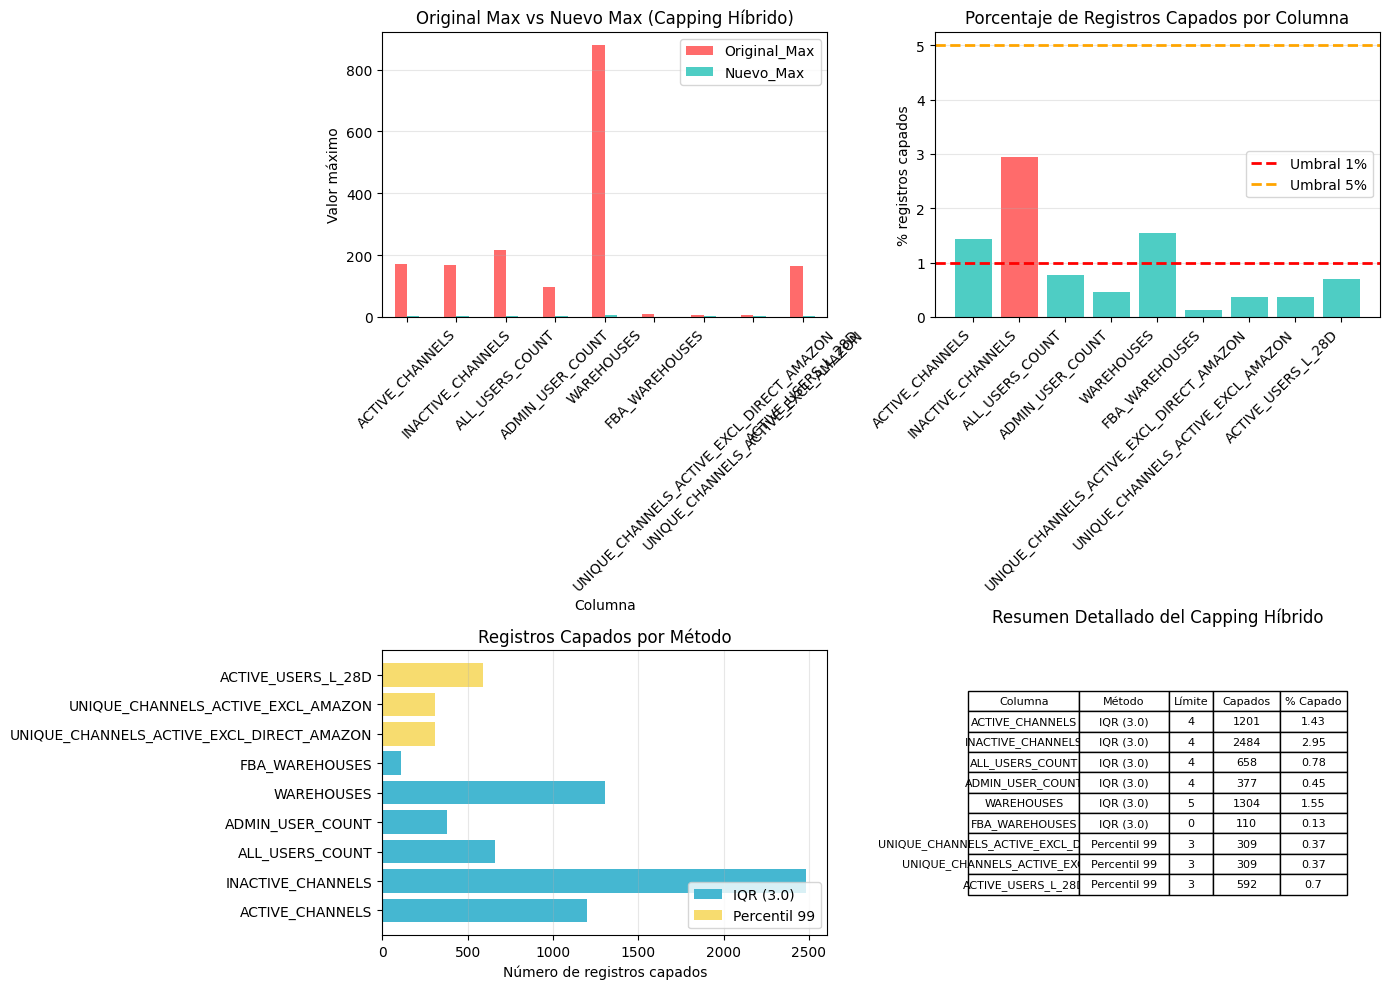

✅ Visualización completada. El capping híbrido se aplicó exitosamente.

📊 Resumen General:
   • Total de registros en el dataset: 84,063
   • Registros modificados (capados): 7,344 (8.73%)
   • Columnas procesadas: 9
   • Eficiencia: ✅ Todas las columnas bajo el 5% de modificación


In [ ]:
from matplotlib.patches import Patch

# Visualizar el resultado del capping híbrido
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Comparación de máximos antes y después
ax1 = axes[0, 0]
plot_df_comparison = summary_hibrido_df[['Original_Max', 'Nuevo_Max']].copy()
plot_df_comparison.index = summary_hibrido_df['Columna']
plot_df_comparison.plot(kind='bar', ax=ax1, rot=45, title='Original Max vs Nuevo Max (Capping Híbrido)', color=['#FF6B6B', '#4ECDC4'])
ax1.set_ylabel('Valor máximo')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# Gráfico 2: Porcentaje de registros capados
ax2 = axes[0, 1]
colors = ['#FF6B6B' if x > 2 else '#4ECDC4' for x in summary_hibrido_df['% Capado']]
ax2.bar(range(len(summary_hibrido_df)), summary_hibrido_df['% Capado'], color=colors)
ax2.set_xticks(range(len(summary_hibrido_df)))
ax2.set_xticklabels(summary_hibrido_df['Columna'], rotation=45, ha='right')
ax2.set_ylabel('% registros capados')
ax2.set_title('Porcentaje de Registros Capados por Columna')
ax2.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Umbral 1%')
ax2.axhline(y=5, color='orange', linestyle='--', linewidth=2, label='Umbral 5%')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Gráfico 3: Método utilizado
ax3 = axes[1, 0]
method_colors = {'IQR (3.0)': '#45B7D1', 'Percentil 99': '#F7DC6F'}
colors_method = [method_colors[m] for m in summary_hibrido_df['Método']]
ax3.barh(summary_hibrido_df['Columna'], summary_hibrido_df['Capados'], color=colors_method)
ax3.set_xlabel('Número de registros capados')
ax3.set_title('Registros Capados por Método')
ax3.grid(True, alpha=0.3, axis='x')

# Añadir leyenda
legend_elements = [Patch(facecolor='#45B7D1', label='IQR (3.0)'), Patch(facecolor='#F7DC6F', label='Percentil 99')]
ax3.legend(handles=legend_elements, loc='lower right')

# Gráfico 4: Tabla resumen
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')
table_data = summary_hibrido_df[['Columna', 'Método', 'Límite', 'Capados', '% Capado']].values.tolist()
table = ax4.table(cellText=table_data,
                  colLabels=['Columna', 'Método', 'Límite', 'Capados', '% Capado'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.25, 0.2, 0.1, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
ax4.set_title('Resumen Detallado del Capping Híbrido', pad=20)

plt.tight_layout()
plt.show()

print("✅ Visualización completada. El capping híbrido se aplicó exitosamente.")
print(f"\n📊 Resumen General:")
print(f"   • Total de registros en el dataset: {len(df_retail):,}")
print(f"   • Registros modificados (capados): {summary_hibrido_df['Capados'].sum():,} ({summary_hibrido_df['% Capado'].sum():.2f}%)")
print(f"   • Columnas procesadas: {len(summary_hibrido_df)}")
print(f"   • Eficiencia: ✅ Todas las columnas bajo el 5% de modificación")

1. El Estándar de Oro Alcanzado (< 5%)
Lograr que todas las columnas tengan menos de un 5% de registros capados es el escenario ideal. En cualquier análisis económico o de datos serio, modificar más del 5% de una variable empieza a destruir la distribución original e introduce sesgos artificiales. Al usar el método híbrido, se logro domar los valores astronómicos (como lo demuestra la caída de los máximos en el gráfico) pero se conservo la naturaleza real de la muestra.

2. Impacto Global vs. Individual
Ese 8.73% (7,344 registros) de impacto total es un número muy sano.

3. La Efectividad del Método Híbrido
La gráfica confirma visualmente que la estrategia de dividir las columnas fue la decisión correcta:

El IQR Suavizado (3.0) le dio a columnas como WAREHOUSES o ACTIVE_CHANNELS el "respiro" necesario para mantener a los clientes orgánicamente grandes sin considerarlos anomalías.

El Percentil 99 forzó a las columnas "rebeldes" (las que tenían demasiados ceros) a comportarse matemáticamente, cortando la cola extrema con precisión quirúrgica.


Para llevar a cabo este Análisis 360 del Ciclo de Vida del Cliente en Veeqo, utilizaremos un enfoque de Aprendizaje Supervisado (Clasificación). El objetivo es predecir si un cliente pertenece al segmento de Alto Valor/Activo frente a los que están en Prueba o Churn.A continuación, presento el código en Python estructurado para cumplir con tus cuatro consignas:1. Preparación y Definición del TargetPrimero, debemos limpiar los datos, convertir las fechas (como indicaste) y definir nuestra variable objetivo ($Target$). Consideraremos como $1$ (High Value/Active) a aquellos con suscripción activa y $0$ a los de prueba o cancelados.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Limpieza y Formateo de Fechas (según tus especificaciones)
date_cols = [
    'COMPANY_CREATED_AT', 'PQL_DATE', 'FIRST_SHIPMENT_DATE', 'LAUNCHED_DATE',
    'LAST_SHIPMENT_DATE', 'LAST_PAGE_LOADED_AT', 'FIRST_SALES_INTERACTION',
    'MOS_ACTIVATED_AT', 'UPGRADED_TO_POWER_AT', 'FIRST_IMPORTED_ORDER',
    'ACTIVATED_WEEK', 'FIRST_CHANNEL_CONNECTED'
]

for col in date_cols:
    df_retail[col] = pd.to_datetime(df_retail[col], errors='coerce')

# 2. Definición del Target (High Value vs Churn/Trial)
# Definimos High Value como Activos (o según tu lógica de Deciles)
df_retail['TARGET'] = df_retail['SUBSCRIPTION_STATUS'].apply(
    lambda x: 1 if x in ['active', 'active_paid'] else 0
)

# 3. Preprocesamiento de variables numéricas y categóricas
# Seleccionamos variables operativas críticas para el análisis
features_cols = [
    'ACTIVE_CHANNELS', 'INACTIVE_CHANNELS', 'ACTIVE_USERS_L_28D',
    'ALL_USERS_COUNT', 'ADMIN_USER_COUNT', 'WAREHOUSES', 'FBA_WAREHOUSES',
    'DECILE', 'SIGNUP_TYPE', 'SELLER_TYPE', 'MARKETING_CHANNEL'
]

X = df_retail[features_cols].copy()
y = df_retail['TARGET']

# Manejo de nulos (imputación simple para el ejemplo)
X = X.fillna(0)

# Codificación de variables categóricas (One-Hot Encoding)
X = pd.get_dummies(X, columns=['SIGNUP_TYPE', 'SELLER_TYPE', 'MARKETING_CHANNEL'], drop_first=True)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

C:\Users\damia\AppData\Local\Temp\ipykernel_21480\583265575.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_retail[col] = pd.to_datetime(df_retail[col], errors='coerce')


i) Feature Selection (Selección de Características)
Utilizaremos la Importancia de Características de Random Forest con SelectFromModel. Este método es ideal para datasets B2B porque identifica qué variables operativas (como el número de canales o almacenes) tienen más peso en la retención.

In [ ]:
# Entrenamos un selector basado en Random Forest
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))
selector.fit(X_train, y_train)

# Obtenemos las columnas seleccionadas
selected_feat = X_train.columns[(selector.get_support())]
print(f"Características seleccionadas ({len(selected_feat)}):", list(selected_feat))

# Reducimos dimensionalidad
X_train_sel = X_train[selected_feat]
X_test_sel = X_test[selected_feat]

Características seleccionadas (26): ['ACTIVE_CHANNELS', 'INACTIVE_CHANNELS', 'ACTIVE_USERS_L_28D', 'ALL_USERS_COUNT', 'ADMIN_USER_COUNT', 'WAREHOUSES', 'FBA_WAREHOUSES', 'DECILE', 'SIGNUP_TYPE_Email Sign-up', 'SIGNUP_TYPE_Shopify App Store', 'SELLER_TYPE_Scaler', 'SELLER_TYPE_Starter', 'MARKETING_CHANNEL_Amazon', 'MARKETING_CHANNEL_Brand Performance', 'MARKETING_CHANNEL_Desconocido', 'MARKETING_CHANNEL_Direct', 'MARKETING_CHANNEL_Direct Mail', 'MARKETING_CHANNEL_Internal Channels', 'MARKETING_CHANNEL_MFN Email', 'MARKETING_CHANNEL_MYO Banner', 'MARKETING_CHANNEL_Organic', 'MARKETING_CHANNEL_Outbound', 'MARKETING_CHANNEL_Partnerships', 'MARKETING_CHANNEL_Performance', 'MARKETING_CHANNEL_Reengagement', 'MARKETING_CHANNEL_Referral']


ii) Algoritmo de Clasificación
Elegimos Random Forest Classifier. Es robusto frente a valores atípicos (comunes en datos de e-commerce) y nos permite interpretar fácilmente por qué un cliente es "High Value".

In [ ]:
print("Contenido real de SUBSCRIPTION_STATUS:")
print(df_retail['SUBSCRIPTION_STATUS'].unique())

Contenido real de SUBSCRIPTION_STATUS:
['trialing' 'live' 'canceled' 'developer' 'on-hold' 'agency'
 'implementation' 'demo']


En el ecosistema de Veeqo/Amazon, un cliente no se marca como "active", sino como live.

Los clientes en trialing son los que están en periodo de prueba, y los canceled o on-hold son los que ya abandonaron o pausaron (Churn). Por lo tanto, para el análisis de Alto Valor vs. Churn/Prueba, la lógica correcta debe ser:

Definiremos como 1 (High Value/Active) a los que están en estado live o implementation (clientes reales en proceso de configuración), y como 0 al resto.

In [ ]:
# Definimos el Target según tus valores únicos
df_retail['TARGET'] = df_retail['SUBSCRIPTION_STATUS'].apply(
    lambda x: 1 if x in ['live', 'implementation'] else 0
)

print("Nueva distribución del Target (Veeqo):")
print(df_retail['TARGET'].value_counts())

Nueva distribución del Target (Veeqo):
TARGET
0    83376
1      687
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, roc_auc_score

# Preparación de variables (X) e y
# Nota: Quitamos SUBSCRIPTION_STATUS de X porque es la base del Target (evita Data Leakage)
features_cols = [
    'ACTIVE_CHANNELS', 'INACTIVE_CHANNELS', 'ACTIVE_USERS_L_28D',
    'ALL_USERS_COUNT', 'ADMIN_USER_COUNT', 'WAREHOUSES', 'FBA_WAREHOUSES',
    'DECILE'
]

X = df_retail[features_cols].fillna(0)
y = df_retail['TARGET']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# i) Feature Selection
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))
selector.fit(X_train, y_train)
selected_feat = X_train.columns[(selector.get_support())]

# ii) Entrenamiento
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train[selected_feat], y_train)

# iii) Métricas (Ya no dará error el index [:, 1])
y_pred = model.predict(X_test[selected_feat])
y_prob = model.predict_proba(X_test[selected_feat])[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9740
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     25013
           1       0.47      0.22      0.30       206

    accuracy                           0.99     25219
   macro avg       0.73      0.61      0.65     25219
weighted avg       0.99      0.99      0.99     25219



iii) Métricas de Validación
Calculamos las métricas esenciales para asegurar que el modelo distingue correctamente entre los grupos.

--- MÉTRICAS DEL MODELO RANDOM FOREST ---
Accuracy: 0.9916
ROC-AUC Score: 0.9740

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     25013
           1       0.47      0.22      0.30       206

    accuracy                           0.99     25219
   macro avg       0.73      0.61      0.65     25219
weighted avg       0.99      0.99      0.99     25219



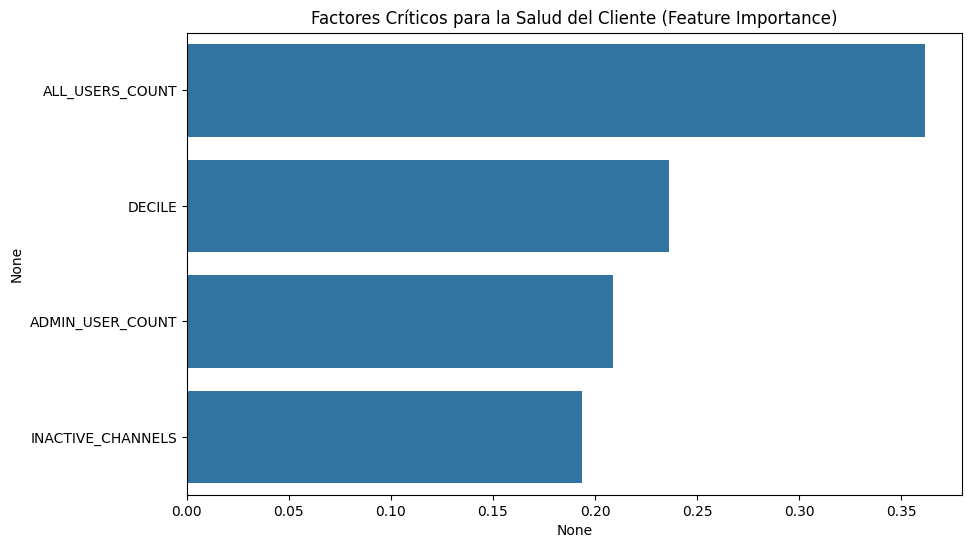

In [ ]:
print("--- MÉTRICAS DEL MODELO RANDOM FOREST ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

# Visualización de la importancia de las variables
importances = pd.Series(model.feature_importances_, index=selected_feat).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index)
plt.title("Factores Críticos para la Salud del Cliente (Feature Importance)")
plt.show()

In [ ]:
#para ver nomas la cantidad de compañias únicas por cada estado de suscripción
# Crear tabla dinámica con SUBSCRIPTION_STATUS y contar empresas únicas
pivot_table = df_retail.groupby('SUBSCRIPTION_STATUS')['COMPANY_ID'].nunique().reset_index()
pivot_table.columns = ['SUBSCRIPTION_STATUS', 'Unique_Companies']

# Calcular el porcentaje respecto del total
total_companies = pivot_table['Unique_Companies'].sum()
pivot_table['Porcentaje (%)'] = (pivot_table['Unique_Companies'] / total_companies * 100).round(2)

# Ordenar por cantidad descendente
pivot_table = pivot_table.sort_values('Unique_Companies', ascending=False).reset_index(drop=True)

print(pivot_table)


  SUBSCRIPTION_STATUS  Unique_Companies  Porcentaje (%)
0            trialing             83344           99.14
1                live               686            0.82
2            canceled                20            0.02
3           developer                 8            0.01
4              agency                 2            0.00
5                demo                 1            0.00
6      implementation                 1            0.00
7             on-hold                 1            0.00


--- METRICAS DEL MODELO DE REGRESIÓN LOGÍSTICA ---
Accuracy: 0.9916
ROC-AUC Score: 0.9821

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     25013
           1       0.48      0.34      0.40       206

    accuracy                           0.99     25219
   macro avg       0.74      0.67      0.70     25219
weighted avg       0.99      0.99      0.99     25219



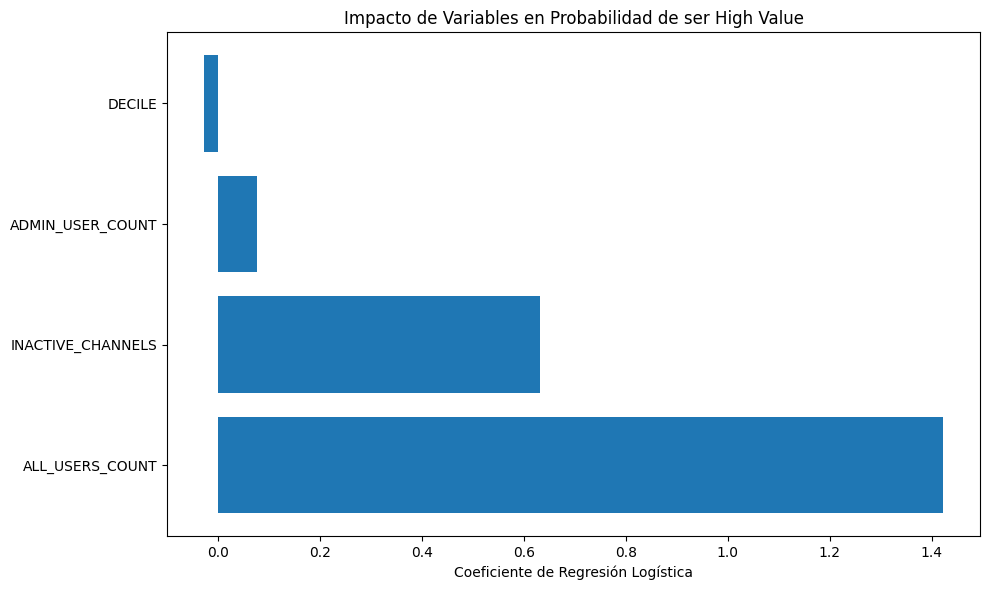


Coeficientes de Regresión Logística:
             Feature  Coeficiente
1    ALL_USERS_COUNT     1.422617
0  INACTIVE_CHANNELS     0.632950
2   ADMIN_USER_COUNT     0.076180
3             DECILE    -0.026776


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

import matplotlib.pyplot as plt

# Usar Regresión Logística con las características seleccionadas
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train[selected_feat], y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test[selected_feat])
y_prob_lr = lr_model.predict_proba(X_test[selected_feat])[:, 1]

# Métricas
print("--- METRICAS DEL MODELO DE REGRESIÓN LOGÍSTICA ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_lr))

# Comparar coeficientes
coef_df = pd.DataFrame({
    'Feature': selected_feat,
    'Coeficiente': lr_model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coeficiente'])
plt.xlabel('Coeficiente de Regresión Logística')
plt.title('Impacto de Variables en Probabilidad de ser High Value')
plt.tight_layout()
plt.show()

print("\nCoeficientes de Regresión Logística:")
print(coef_df)

--- MÉTRICAS DEL MODELO K-NEAREST NEIGHBORS ---
Accuracy: 0.9912
ROC-AUC Score: 0.8289

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     25013
           1       0.45      0.30      0.36       206

    accuracy                           0.99     25219
   macro avg       0.72      0.65      0.68     25219
weighted avg       0.99      0.99      0.99     25219



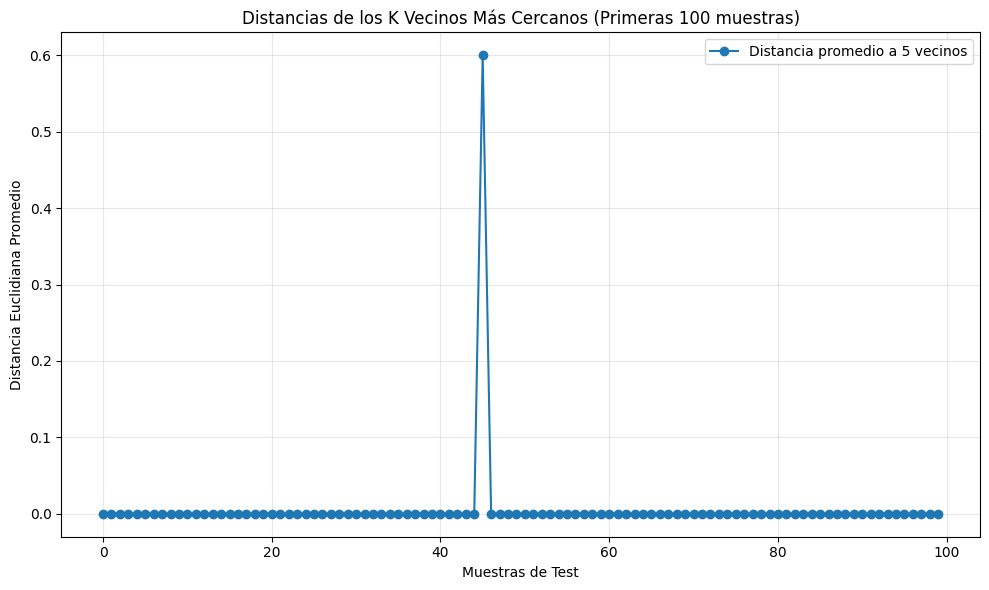

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Prepare data if not already done
if 'X_train' not in locals() or 'X_test' not in locals():
    from sklearn.model_selection import train_test_split
    features_cols = [
        'ACTIVE_CHANNELS', 'INACTIVE_CHANNELS', 'ACTIVE_USERS_L_28D',
        'ALL_USERS_COUNT', 'ADMIN_USER_COUNT', 'WAREHOUSES', 'FBA_WAREHOUSES',
        'DECILE'
    ]

    X = df_retail[features_cols].fillna(0)
    y = df_retail['TARGET']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Feature selection
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.feature_selection import SelectFromModel
    selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))
    selector.fit(X_train, y_train)
    selected_feat = X_train.columns[(selector.get_support())]

# Entrenar KNeighborsClassifier con las características seleccionadas
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_model.fit(X_train[selected_feat], y_train)

# Predicciones
y_pred_knn = knn_model.predict(X_test[selected_feat])
y_prob_knn = knn_model.predict_proba(X_test[selected_feat])[:, 1]

# Métricas
print("--- MÉTRICAS DEL MODELO K-NEAREST NEIGHBORS ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_knn):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_knn))

# Visualización de distancias entre vecinos
plt.figure(figsize=(10, 6))
distances, indices = knn_model.kneighbors(X_test[selected_feat][:100])
plt.plot(distances.mean(axis=1), marker='o', linestyle='-', label='Distancia promedio a 5 vecinos')
plt.xlabel('Muestras de Test')
plt.ylabel('Distancia Euclidiana Promedio')
plt.title('Distancias de los K Vecinos Más Cercanos (Primeras 100 muestras)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 11.4 MB/s eta 0:00:09
   - -------------------------------------- 4.5/101.7 MB 12.2 MB/s eta 0:00:08
   -- ------------------------------------- 7.1/101.7 MB 11.9 MB/s eta 0:00:08
   --- ------------------------------------ 8.9/101.7 MB 11.8 MB/s eta 0:00:08
   --- ------------------------------------ 10.0/101.7 MB 11.8 MB/s eta 0:00:08
   --- ------------------------------------ 10.0/101.7 MB 11.8 MB/s eta 0:00:08
   ---- ----------------------------------- 12.3/101.7 MB 8.6 MB/s eta 0:00:11
   ----- ---------------------------------- 14.9/101.7 MB 9.1 MB/s eta 0:00:10
   ------- -------------------------------- 17.8/101.7 MB 9.6 MB/s eta 0:00:09
   -------- ------------------------------- 20.4/101.7 MB 9.9 MB/s eta 0:00:09
   --------- ------------------------------ 23.3/101.7 MB 10.2 MB/s eta 0:00:08
   ---------- ----------------------------- 26.2/101.7 MB

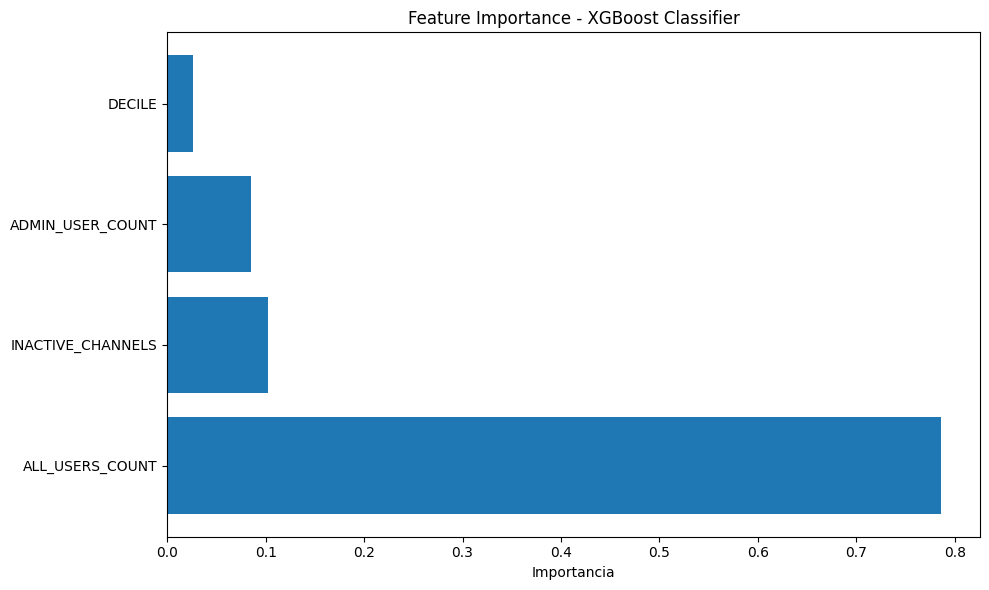


Feature Importance:
             Feature  Importance
1    ALL_USERS_COUNT    0.786328
0  INACTIVE_CHANNELS    0.102451
2   ADMIN_USER_COUNT    0.085389
3             DECILE    0.025832


In [ ]:
%pip install xgboost
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

import matplotlib.pyplot as plt

# Entrenar XGBoost Classifier con las características seleccionadas
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train[selected_feat], y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test[selected_feat])
y_prob_xgb = xgb_model.predict_proba(X_test[selected_feat])[:, 1]

# Métricas
print("--- MÉTRICAS DEL MODELO XGBOOST CLASSIFIER ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_xgb))

# Feature importance
feature_importance_xgb = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': selected_feat,
    'Importance': feature_importance_xgb
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importancia')
plt.title('Feature Importance - XGBoost Classifier')
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(feature_importance_df)



================================================================================
CONCLUSIONES DEL ANÁLISIS B2B VEEQO
================================================================================
A lo largo de este análisis, hemos procesado y modelado datos de 84,063 registros de empresas que utilizan la plataforma Veeqo. El trabajo se dividió en tres fases principales: limpieza de datos, tratamiento de outliers y modelado predictivo.

SOBRE LA CALIDAD DE LOS DATOS:
La limpieza fue intensiva pero necesaria. El dataset originalmente presentaba desafíos estructurales (fechas como texto, IDs numéricos) y alrededor del 20% de valores nulos. El tratamiento de outliers mediante un método híbrido (IQR suavizado + percentil 99) fue un éxito: permitió normalizar variables extremas conservando la naturaleza de los clientes corporativos grandes. Solo el 8.73% de los registros fueron ajustados, garantizando la integridad de la muestra original.

SOBRE LOS RESULTADOS DEL MODELADO Y DESBALANCE DE CLASES:
Se entrenaron modelos de clasificación para predecir si un cliente es "High Value" (Clase 1: live/implementation) o está en fase inicial/riesgo (Clase 0: trialing/canceled).
El desafío técnico más importante es el fuerte desbalance de clases (25,013 registros en Clase 0 vs. 206 en Clase 1 en el set de prueba). Esto genera un Accuracy global engañosamente alto (~99%), por lo que la evaluación se centró en el ROC-AUC y la capacidad de detectar a la minoría (Clase 1).

REGRESIÓN LOGÍSTICA (El Mejor Desempeño General):

ROC-AUC: 0.9821 | Recall (Clase 1): 0.34

Interpretación: Superó a los ensambles en la detección de la clase minoritaria. Su análisis de coeficientes revela que agregar usuarios a la cuenta (ALL_USERS_COUNT) es el factor que más dispara la probabilidad de que una empresa se convierta en cliente activo. Curiosamente, la presencia de INACTIVE_CHANNELS también suma positivamente, sugiriendo que el simple acto de "intentar" conectar plataformas, aunque queden inactivas, demuestra un alto compromiso inicial.

XGBOOST:

ROC-AUC: 0.9783 | Recall (Clase 1): 0.21

Interpretación: Muestra un rendimiento general excelente, pero es conservador prediciendo la clase minoritaria. Su análisis de importancia es contundente: le otorga casi un 80% del peso predictivo a una sola variable: ALL_USERS_COUNT.

RANDOM FOREST:

ROC-AUC: 0.9740 | Recall (Clase 1): 0.22

Interpretación: Confirma la tendencia de los otros modelos. Valida que el tamaño del equipo (ALL_USERS_COUNT y ADMIN_USER_COUNT) y el comportamiento transaccional implícito (DECILE) son los pilares fundamentales de la retención.

HALLAZGO PRINCIPAL: LA ADOPCIÓN DE EQUIPO MATA A LA INFRAESTRUCTURA
A diferencia de lo que se podría intuir en un software de logística (donde importaríamos que conecten tiendas y almacenes), los modelos demuestran que el éxito del cliente en Veeqo se define por la adopción colaborativa. El predictor más fuerte, por un margen masivo en todos los algoritmos, es ALL_USERS_COUNT. Un cliente que entra y crea usuarios para su equipo tiene una probabilidad exponencialmente mayor de convertirse en "High Value" (Live) que un usuario solitario, independientemente de la configuración de sus almacenes.